# Module Assignment 3 - Data Challenge

**Task:** to build a model that predictst the nightly price of a listing as accurately as possible and submit those predictions as a CSV file. 

**My Approach to this MA:**
1. I used linear regression to predict the price
2. I used k-means to group the listings into locations and used it as a feature selection
3. Feature selection took some time to work through. I was able to fill in the missing data, where i used one-hot encoding for the categorical columns. I also decided to use `amenities` as a feature by trying to find out how much price is impacted by the amenities that a listing has to offer.

## Check Setup

This cell installs any missing packages into the active Jupyter kernel.

In [7]:
import importlib.util
import subprocess
import sys

required_packages = {
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "sklearn": "scikit-learn",
}

missing_packages = [
    package_name
    for import_name, package_name in required_packages.items()
    if importlib.util.find_spec(import_name) is None
]

if missing_packages:
    print("Installing missing packages:", ", ".join(missing_packages))
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing_packages])
else:
    print("All required packages are installed.")

All required packages are installed.


## Import Libraries

We will use:

- `pandas` and `numpy` for data work
- `matplotlib` for charts
- `StandardScaler` to normalize the features, and `OneHotEncoder` to change the categorical columns into numbers (for example the room_type, neighbourhood, location_cluster)
- `K-Means` to group listings into location clusters
- `LinearRegression` to predict the price
- `train_test_split` plus the `mean_squared_error` (for RMSE) and `mean_absolute_error`, `r2_score` will be used to evaluate the model

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split

## Load The Dataset

In [28]:
train_df = pd.read_csv('listings_train.csv')
test_df = pd.read_csv('listings_test_features.csv')

## Inspect The Data

Before doing anything with the data, I looked at the data types and also checked to see where the missing values are.

In [29]:
train_df.info()
display(train_df.describe())
train_df

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42234 entries, 0 to 42233
Data columns (total 36 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              42234 non-null  float64
 1   name                            42234 non-null  object 
 2   host_id                         42234 non-null  int64  
 3   host_name                       42216 non-null  object 
 4   host_total_listings_count       42218 non-null  float64
 5   host_has_profile_pic            42218 non-null  object 
 6   host_identity_verified          42218 non-null  object 
 7   neighbourhood_group             0 non-null      float64
 8   neighbourhood                   42234 non-null  object 
 9   latitude                        42234 non-null  float64
 10  longitude                       42234 non-null  float64
 11  room_type                       42234 non-null  object 
 12  minimum_nights                  

,id,host_id,host_total_listings_count,neighbourhood_group,latitude,longitude,minimum_nights,calculated_host_listings_count,availability_365,number_of_reviews_ltm,...,reviews_per_month,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,price
count,4.223400e+04,4.223400e+04,42218.000000,0.0,42234.000000,42234.000000,42234.000000,42234.000000,42234.000000,42234.000000,...,33099.000000,33099.000000,33098.000000,33098.000000,33097.000000,33098.000000,33097.000000,33097.00000,0.0,42234.000000
mean,8.993349e+17,2.583441e+08,101.437088,NaN,51.509859,-0.132020,5.073401,20.487735,214.048705,8.045698,...,1.289538,4.672812,4.706610,4.659316,4.778300,4.798594,4.733334,4.58664,NaN,166.242743
std,5.391873e+17,2.326461e+08,680.747344,NaN,0.047786,0.100010,18.588886,58.075589,121.665001,13.632750,...,1.409859,0.503092,0.490562,0.502755,0.437346,0.438992,0.410206,0.52088,NaN,98.380093
min,1.391300e+04,2.594000e+03,1.000000,NaN,51.295937,-0.496075,1.000000,1.000000,0.000000,0.000000,...,0.010000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,NaN,50.000000
25%,6.337215e+17,3.432110e+07,2.000000,NaN,51.487090,-0.192176,1.000000,1.000000,92.000000,0.000000,...,0.340000,4.570000,4.650000,4.550000,4.750000,4.780000,4.670000,4.50000,NaN,90.000000
50%,1.076795e+18,1.860463e+08,5.000000,NaN,51.513580,-0.135140,2.000000,3.000000,242.000000,2.000000,...,0.840000,4.820000,4.860000,4.800000,4.920000,4.950000,4.850000,4.71000,NaN,141.000000
75%,1.352515e+18,4.830355e+08,25.000000,NaN,51.536787,-0.073803,3.000000,14.000000,333.000000,10.000000,...,1.740000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,4.89000,NaN,215.000000
max,1.508964e+18,7.186905e+08,8769.000000,NaN,51.682630,0.275100,999.000000,500.000000,365.000000,246.000000,...,36.960000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.00000,NaN,500.000000


,id,name,host_id,host_name,host_total_listings_count,host_has_profile_pic,host_identity_verified,neighbourhood_group,neighbourhood,latitude,...,reviews_per_month,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,price
0,8.637189e+17,One bedroom modern flat stunning central London,508846510,Lin,1.0,t,t,NaN,Hammersmith and Fulham,51.473060,...,1.06,4.71,4.71,4.58,4.65,4.87,4.77,4.65,NaN,104
1,1.246273e+18,Modern 1BR Flat in Central Brixton – Asaph House,229912595,Nicole,23.0,t,t,NaN,Lambeth,51.461770,...,0.32,5.00,5.00,5.00,5.00,5.00,5.00,5.00,NaN,219
2,9.958368e+17,Suite-Deluxe-Ensuite-Street View-6,491436321,Ada Leo,26.0,t,t,NaN,Hackney,51.545587,...,0.86,4.00,4.25,4.00,4.25,4.50,4.00,4.00,NaN,96
3,8.884977e+17,Single Room with shared bathroom in central Lo...,513462549,Manor,4.0,f,t,NaN,Kensington and Chelsea,51.492899,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,200
4,1.069328e+18,Canary Wharf Retreat with Free Secure Parking,1432477,Maxime,791.0,t,t,NaN,Tower Hamlets,51.498470,...,0.87,4.82,4.82,5.00,4.65,4.88,4.88,4.82,NaN,261
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42229,5.266754e+07,Lovely bedroom in a large flat,205722011,Manon,3.0,t,t,NaN,Lambeth,51.460710,...,0.07,4.67,4.33,4.33,4.00,4.67,5.00,4.00,NaN,82
42230,1.424101e+18,River view 2 bedroom flat,696260456,Daniel,1.0,t,t,NaN,Tower Hamlets,51.490970,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,149
42231,1.328874e+18,Charming West London Mews House,10468628,Freya,4.0,t,t,NaN,Hammersmith and Fulham,51.488560,...,1.91,5.00,5.00,4.33,5.00,5.00,4.67,4.67,NaN,416
42232,2.576995e+06,"Dbl Room, W'stow Central 2 mins",8220928,Joanna,1.0,t,t,NaN,Waltham Forest,51.582153,...,3.00,5.00,5.00,5.00,4.67,5.00,5.00,5.00,NaN,50


In [30]:
test_df.info()
display(test_df.describe())
test_df

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8199 entries, 0 to 8198
Data columns (total 35 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              8199 non-null   float64
 1   name                            8199 non-null   object 
 2   host_id                         8199 non-null   int64  
 3   host_name                       8199 non-null   object 
 4   host_total_listings_count       8199 non-null   int64  
 5   host_has_profile_pic            8199 non-null   object 
 6   host_identity_verified          8199 non-null   object 
 7   neighbourhood_group             0 non-null      float64
 8   neighbourhood                   8199 non-null   object 
 9   latitude                        8199 non-null   float64
 10  longitude                       8199 non-null   float64
 11  room_type                       8199 non-null   object 
 12  minimum_nights                  81

,id,host_id,host_total_listings_count,neighbourhood_group,latitude,longitude,minimum_nights,calculated_host_listings_count,availability_365,number_of_reviews_ltm,...,number_of_reviews,reviews_per_month,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license
count,8.199000e+03,8.199000e+03,8199.000000,0.0,8199.000000,8199.000000,8199.000000,8199.000000,8199.000000,8199.000000,...,8199.000000,8199.000000,8199.000000,8199.000000,8199.000000,8199.000000,8199.000000,8199.000000,8199.000000,0.0
mean,8.111947e+17,2.401778e+08,54.689474,NaN,51.510278,-0.132649,4.259422,16.681303,201.765581,10.262349,...,33.849982,1.264060,4.663313,4.703457,4.655154,4.777879,4.793047,4.725021,4.580500,NaN
std,5.471469e+17,2.286321e+08,387.128267,NaN,0.046830,0.097168,16.877908,42.146775,119.914823,15.159978,...,60.421421,1.382557,0.528081,0.501325,0.516702,0.446540,0.456056,0.425987,0.538581,NaN
min,3.629900e+04,6.774000e+03,1.000000,NaN,51.297899,-0.495127,1.000000,1.000000,0.000000,0.000000,...,1.000000,0.010000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,NaN
25%,5.134037e+07,2.973693e+07,2.000000,NaN,51.487233,-0.191921,1.000000,1.000000,88.000000,1.000000,...,4.000000,0.330000,4.570000,4.640000,4.540000,4.750000,4.780000,4.660000,4.490000,NaN
50%,9.738647e+17,1.499759e+08,5.000000,NaN,51.513360,-0.134518,2.000000,3.000000,217.000000,5.000000,...,12.000000,0.820000,4.820000,4.850000,4.800000,4.910000,4.940000,4.840000,4.710000,NaN
75%,1.280213e+18,4.673870e+08,23.000000,NaN,51.535791,-0.074147,3.000000,13.000000,319.000000,13.000000,...,37.000000,1.710000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,4.890000,NaN
max,1.505850e+18,7.179293e+08,8769.000000,NaN,51.680130,0.278960,600.000000,500.000000,365.000000,390.000000,...,849.000000,17.130000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,NaN


,id,name,host_id,host_name,host_total_listings_count,host_has_profile_pic,host_identity_verified,neighbourhood_group,neighbourhood,latitude,...,last_review,reviews_per_month,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license
0,1.136690e+18,chill flat,81356851,Sylwia,1,t,f,NaN,Barnet,51.626248,...,2025-07-20,0.30,5.00,5.00,5.00,4.75,5.00,5.00,5.00,NaN
1,6.919139e+06,2014 VW Camper called Viv,7724775,Jenna,1,t,t,NaN,Lewisham,51.428070,...,2024-08-19,0.09,5.00,5.00,4.89,5.00,5.00,5.00,5.00,NaN
2,1.376724e+18,Elegant City Stay steps to Oxford Street,594523926,Fabio,12,t,t,NaN,Camden,51.520461,...,2025-07-02,0.68,3.33,4.00,3.67,4.00,3.67,4.00,3.33,NaN
3,1.365046e+18,Indigo Flats Chic Apartment 2 West End,29024847,Sarah,96,t,t,NaN,Westminster,51.513179,...,2025-07-14,0.46,5.00,5.00,5.00,5.00,5.00,5.00,5.00,NaN
4,1.385436e+18,Holloway 3-BR flat w. Private Patio near Camden,661844715,Anna,49,t,t,NaN,Islington,51.551530,...,2025-09-08,3.28,4.71,4.64,4.57,4.57,4.71,4.79,4.79,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8194,2.170603e+07,Chic Getaway In Chelsea,158024537,Lucy,2,t,t,NaN,Kensington and Chelsea,51.492100,...,2025-08-03,0.54,4.76,4.92,4.86,4.96,4.98,4.96,4.69,NaN
8195,7.572697e+17,Bright Bedroom - 7 mins to Buckingham Palace,20366937,Jon,1,t,t,NaN,Wandsworth,51.460048,...,2024-09-02,0.50,4.41,4.41,3.94,4.76,4.76,4.94,4.29,NaN
8196,1.113756e+18,Comely Deluxe South Central London Apartment,12291293,Jay,61,t,t,NaN,Southwark,51.485010,...,2025-09-09,3.46,4.61,4.76,4.78,4.66,4.78,4.08,4.59,NaN
8197,1.330432e+18,Baker Street Stylish Getaway 2BR,202552824,Mohammed,27,t,t,NaN,Westminster,51.519840,...,2025-07-27,0.88,4.00,4.00,3.33,3.67,4.00,4.33,4.00,NaN


## EDA / Data Exploration

### 0. Framing:

The type of this problem is supervised learning, more specifically regression. The target is `price`, a continuous numerical value that we're trying to predict. It's supervised learning because the training data includes known `price` labels that it leearns from. 

The only column in training data but not in the test is `price`, which is the target we're trying to predict.

### 1. Data Quality

In [31]:
print("training shape:", train_df.shape)
print("test shape:", test_df.shape)
print("columns in training but not in test:", set(train_df.columns) - set(test_df.columns))

# Check missing values & drop missing data reference: https://pandas.pydata.org/docs/user_guide/missing_data.html 
missing = train_df.isna().sum()
# Apply masking and display only the columns that have missing values
display(missing[missing > 0].sort_values(ascending=False))
kept = train_df.drop(columns=["neighbourhood_group", "license"])
usable = kept.dropna()
print("usable as is:", usable.shape[0])

training shape: (42234, 36)
test shape: (8199, 35)
columns in training but not in test: {'price'}


license                        42234
neighbourhood_group            42234
review_scores_value             9137
review_scores_location          9137
review_scores_checkin           9137
review_scores_communication     9136
review_scores_cleanliness       9136
review_scores_accuracy          9136
review_scores_rating            9135
reviews_per_month               9135
last_review                     9135
beds                              80
bedrooms                          47
bathrooms                         42
host_name                         18
host_total_listings_count         16
host_identity_verified            16
host_has_profile_pic              16
dtype: int64

usable as is: 33015


### Data Quality Questions
1. How many columns are there in the training set?

   **Response**: 36 columns
   
2. How many columns are there in the test set?

   **Response**: 35 columns

3. Where do they match/mismatch?

   **Response**: The training data set includes one extra column `price`, where the test data set does not

4. Which contain missing values?

   **Response**: The 18 columns that are shown above (those with missing count > 0). 

5. How many rows are there in the training set?

   **Response**: 42234 rows

6. How many rows are there in the test set?

   **Response**: 8199 rows

7. How many are usable as is?

   **Response**: 33015 rows

8. How do i plan to handle the missing values?

   **Response**: I noticed that `neighbourhood_group` and `license` are all empty, so i dropped those columns. For those columns that have partially missing data, I will fill them instead of dropping the rows. For example, `review_per_month` will be filled with 0's since missing values means the listing has no reviews. Columns like `host_has_profile_pic` will be filled with t/f and filling the missing values with 0. 

### 2. Distributions

#### Plot the Histogram

This plot shows the distribution of prices (price vs. count of listings). 

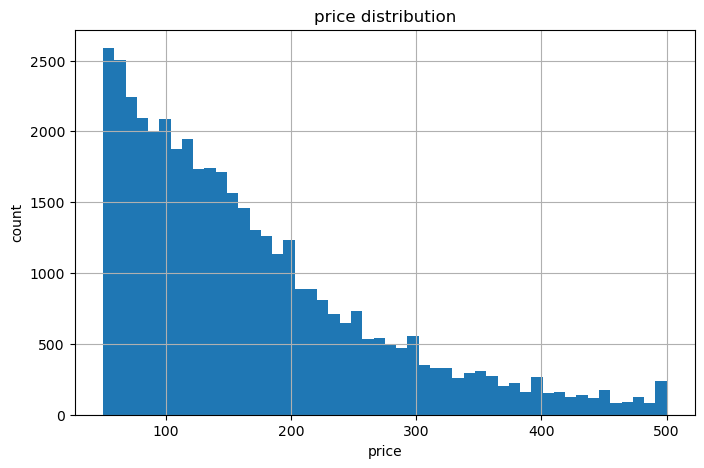

count    42234.000000
mean       166.242743
std         98.380093
min         50.000000
25%         90.000000
50%        141.000000
75%        215.000000
max        500.000000
Name: price, dtype: float64

name                      41118
amenities                 38642
host_name                  9090
last_review                1660
neighbourhood                33
room_type                     4
host_has_profile_pic          2
host_identity_verified        2
dtype: int64

In [32]:
plt.figure(figsize=(8, 5))
# Histplot reference: https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.hist.html
plt.hist(train_df["price"], bins=50)
plt.xlabel("price")
plt.ylabel("count")
plt.title("price distribution")
plt.grid(True)
plt.show()

display(train_df["price"].describe())
# How many unique values does each non-numeric column have?
# How to get the dataframe’s columns based on the column dtypes reference: https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.select_dtypes.html
unique = train_df.select_dtypes(include="object").nunique().sort_values(ascending=False)
display(unique)

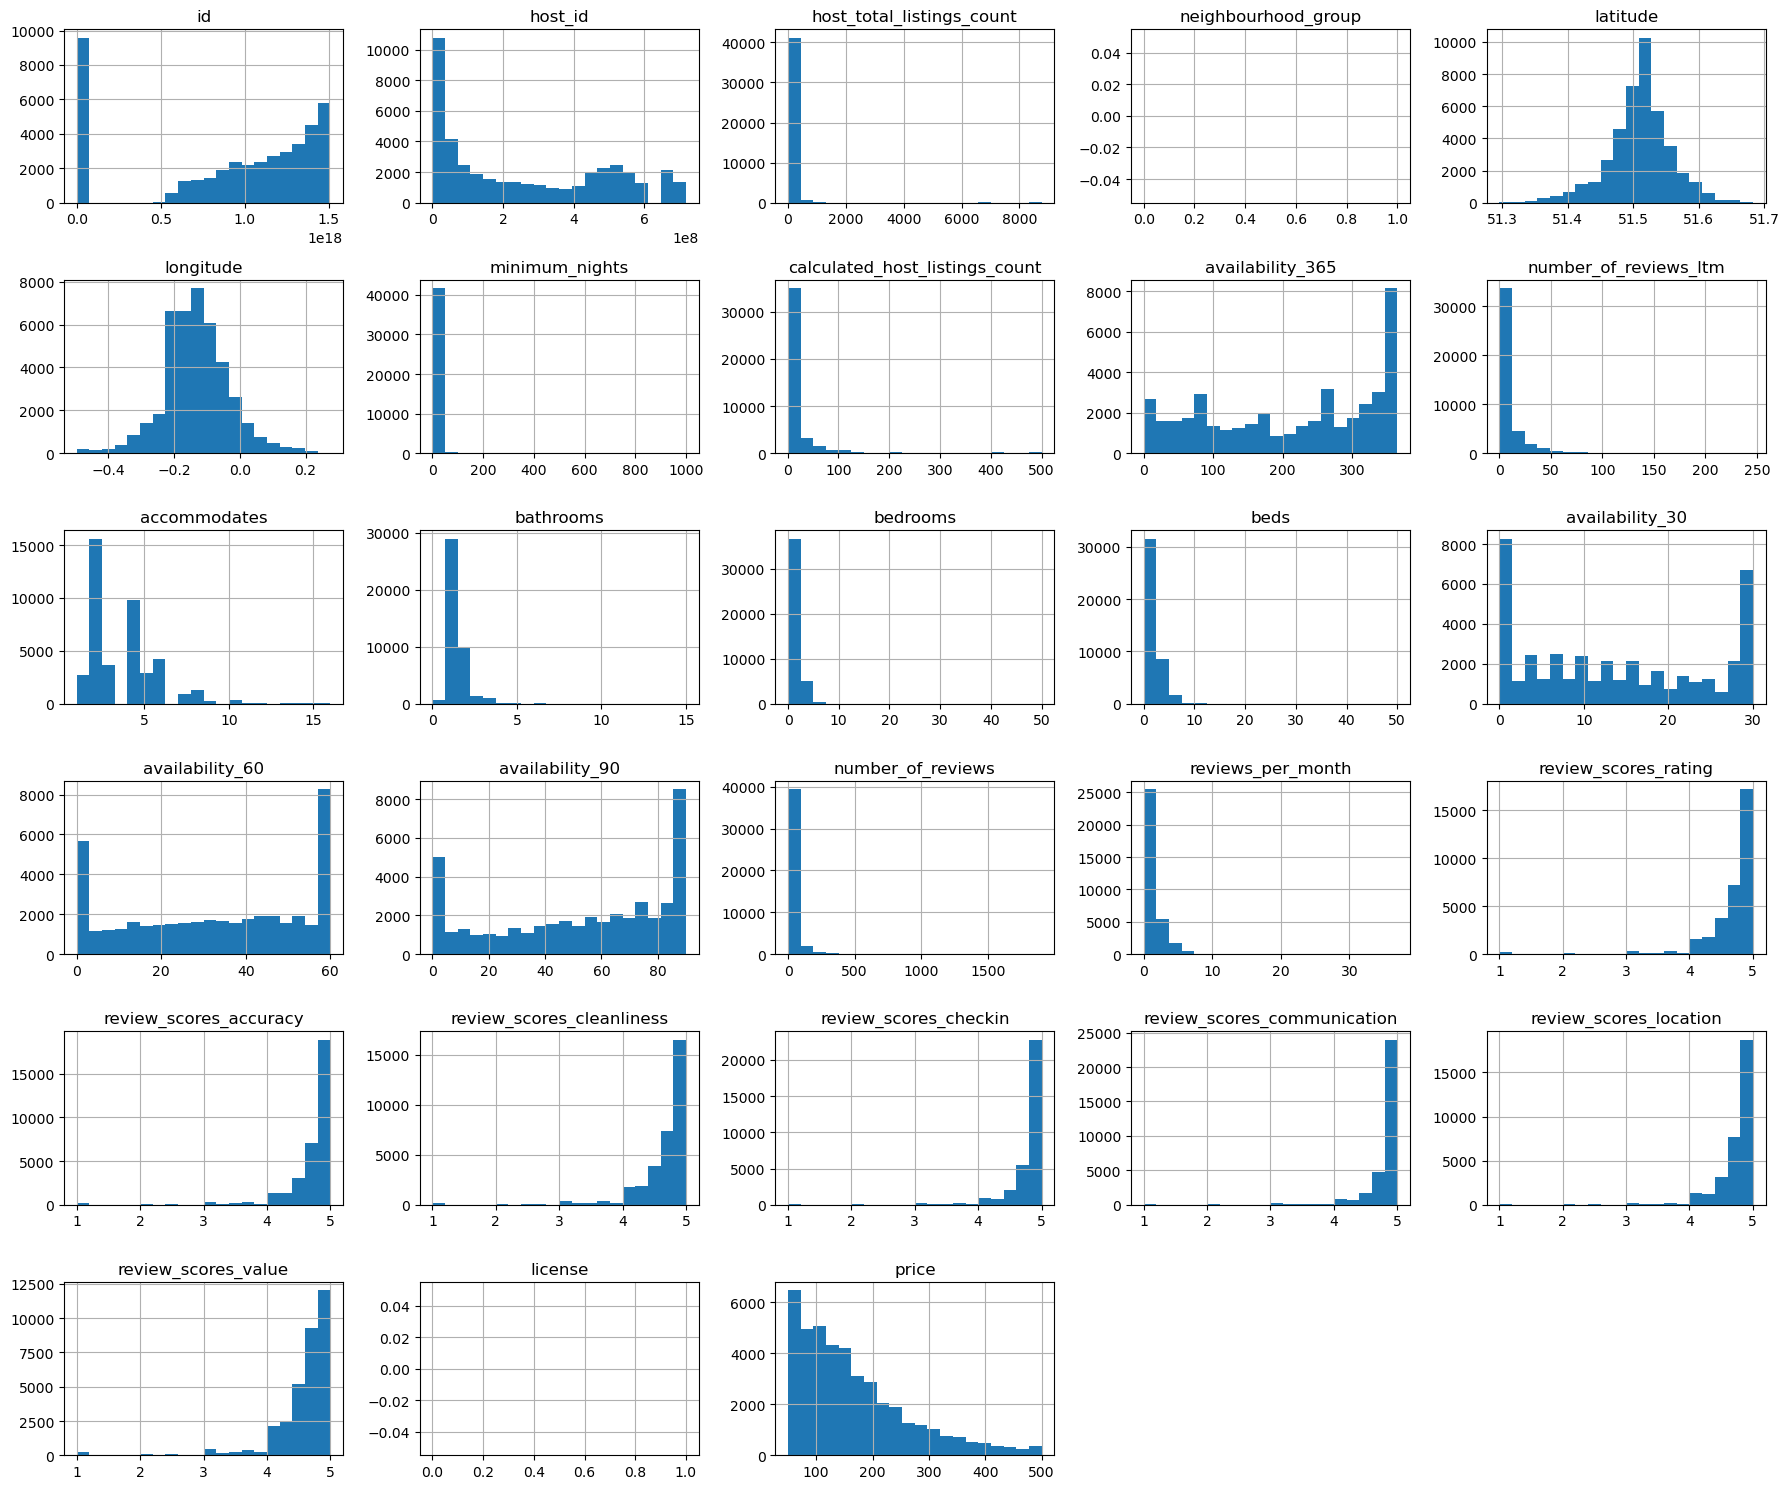

In [33]:
# Histogram of every column with numeric values, my goal is to get an overview of what is skewed and what is normal
train_df.hist(figsize=(18,15), bins=20)
# matplotlib.pylot layout reference: https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.tight_layout.html#matplotlib.pyplot.tight_layout
plt.tight_layout()
plt.show()

### Distribution Questions
1. Is price normally distributed?

   **Response**: The `price` is not noramlly distributed, the histogram shows that it's skewed to the right and it stops at 500. 
   
2. What is the median price?

   **Response**: The median price is 141 with a mean of ~166.

3. How are features distributed - normally / not normally?

   **Response**: Shown above this cell: most of the numeric features are skewed to the left or right, many are not normally distributed.

4. How many unique values does each non-numeric columns (eg. neighbourhood) have?

   **Response**: Shown in the table printed above. `name` has 41118, `amenities` has 38642, `neighbourhood` has 33, `room_type` has 4 etc.

5. How will you handle these columns?

   **Response**: I will one hot encode the categories like `neighbourhood` and `room_type`. I noticed `amenities` are in lists so i will consider this and count it with a variable called `amenity_count`. I will also drop `name` and `host_name` because it is unique to every listing title/person, so it's not going to be very much useful. `last_review` will also be dropped because I don't think it's necessary for the modeling. I'll also add the true or false flags for `host_has_profile_pic` and `host_identity_verified`.

# Data Cleaning & Feature Engineering

In [36]:
# target = price
y = train_df["price"]
X = train_df.copy()
X_test = test_df.copy()

In [37]:
# change the t/f columns to 1 or 0 so they become numeric values that the linear regression model can actually use
bool_cols = ["host_has_profile_pic", "host_identity_verified"]
mapping = {"t": 1, "f": 0}
for col in bool_cols:
    X[col] = X[col].map(mapping)
    X_test[col] = X_test[col].map(mapping)

# Fill data reference: https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.fillna.html
# Fill the rows that don't have t/f with 0
X[bool_cols] = X[bool_cols].fillna(0)
X_test[bool_cols] = X_test[bool_cols].fillna(0)

### Amenities

I wanted to find out how the amenities list affects the price. I approached this by gathering a list of `candidates` (Most of these I selected because they're quite common across airbnb listings). The goal is to find out which amenities have the highest impact on the median price, then I turn the largest ones into 0/1 flags similar to what I did for the t/f columns.

In [38]:
low = train_df["amenities"].str.lower()
candidates = [
    "Air conditioning", "TV", "Dishwasher", "Kitchen", "Washer", "Elevator", "Gym", "Pool", "Bathtub", "Coffee", "Iron", "Dryer", "Refrigerator", "Hair dryer", "Private entrance", "Microwave", "balcony", "Patio", "Heating", "First aid kit", "Hot tub", "view", "Waterfront", "Self check-in",
]
gaps = []
for amenity in candidates:
    includes = low.str.contains(amenity.lower(), regex=False)
    price_gap = train_df.loc[includes, "price"].median() - train_df.loc[~includes, "price"].median()
    gaps.append({"amenity": amenity, "price_gap": price_gap})
gaps = pd.DataFrame(gaps).sort_values("price_gap", ascending=False)
display(gaps)

,amenity,price_gap
0,Air conditioning,79.0
1,TV,70.0
2,Dishwasher,67.0
3,Kitchen,55.0
4,Washer,54.0
5,Elevator,49.0
6,Gym,42.0
7,Pool,41.0
8,Bathtub,35.0
9,Coffee,35.0


In [39]:
# Kept the top results from above, those have the biggest impact
amenity_tags = [
    "Air conditioning", "TV", "Dishwasher", "Kitchen", "Washer", "Elevator"
]
train_amenities = train_df["amenities"].str.lower()
test_amenities = test_df["amenities"].str.lower()
show_cols = []
for amenity in amenity_tags:
    col = "a_" + amenity.replace(" ", "_")
    X[col] = train_amenities.str.contains(amenity.lower(), regex=False).astype(int)
    X_test[col] = test_amenities.str.contains(amenity.lower(), regex=False).astype(int)
    show_cols.append(col)

print("Training:")
display(X[show_cols].head())
print("Testing:")
display(X_test[show_cols].head())
print("Sum:")
display(X[show_cols].sum())

Training:


,a_Air_conditioning,a_TV,a_Dishwasher,a_Kitchen,a_Washer,a_Elevator
0,1,1,0,1,1,1
1,0,1,0,1,1,0
2,0,1,0,1,1,0
3,0,1,0,0,0,0
4,0,1,1,1,1,1


Testing:


,a_Air_conditioning,a_TV,a_Dishwasher,a_Kitchen,a_Washer,a_Elevator
0,0,1,1,1,1,0
1,0,0,0,1,0,0
2,0,1,0,1,1,1
3,0,1,1,1,1,0
4,0,1,1,1,1,0


Sum:


a_Air_conditioning     4918
a_TV                  34785
a_Dishwasher          17014
a_Kitchen             38720
a_Washer              37129
a_Elevator             7556
dtype: int64

### Filling in Missing Values

Fill in data for some of the missing numeric columns using training mean. For example, if there's no data in `reviews_per_month`, then i fill it with 0 because it indicates that this listing has no reviews.

In [40]:
# Filling in other missing values with the column's mean 
fill_cols = [
    "review_scores_value", "review_scores_location", "review_scores_checkin", "review_scores_communication", "review_scores_cleanliness", "review_scores_accuracy", "review_scores_rating", "beds", "bedrooms", "bathrooms", "host_total_listings_count"
]

for col in fill_cols:
    mean_val = X[col].mean()
    X[col] = X[col].fillna(mean_val)
    X_test[col] = X_test[col].fillna(mean_val)

X["reviews_per_month"] = X["reviews_per_month"].fillna(0)
X_test["reviews_per_month"] = X_test["reviews_per_month"].fillna(0)

### Using K-means to Clusters Based on Listings by Location

Since lat/long can't be used well for linear regression, I group the listings into location clusters and used the results as a feature. I was genuinely curious whether location affects the price of the stay (real-world experience shows it does). 

In [41]:
coordinate_cols = ["latitude", "longitude"]
coordinate_scaler = StandardScaler()
coordinate_train = coordinate_scaler.fit_transform(X[coordinate_cols])
coordinate_test = coordinate_scaler.transform(X_test[coordinate_cols])

kmeans = KMeans(n_clusters=15, n_init=10, max_iter=300, tol=0.0001, random_state=42)
X["location_cluster"] = kmeans.fit_predict(coordinate_train)
X_test["location_cluster"] = kmeans.predict(coordinate_test)
X["location_cluster"].value_counts()

location_cluster
9     6790
5     5914
10    5872
0     5075
11    3421
3     2679
1     2165
2     2070
8     1901
13    1809
4     1199
14     942
6      934
7      854
12     609
Name: count, dtype: int64

In [42]:
# Drop columns that are now not useful anymore, we've either filled in data for those columns or dropped it entirely
drop_cols = [
    "id", "name", "host_id", "host_name", "neighbourhood_group", "license", "latitude", "longitude", "amenities", "last_review",
]

X = X.drop(columns=drop_cols + ["price"])
X_test = X_test.drop(columns=drop_cols)

### One-hot Encoding the Categories

`room_type`, `neighbourhood`, and `location_cluster` are all categories, so I decided to one-hot encode them. 

In [43]:
# One-hot encoding reference: https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html
ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

category_cols = ["room_type", "neighbourhood", "location_cluster"]
train_category = ohe.fit_transform(X[category_cols])
test_category = ohe.transform(X_test[category_cols])

names = ohe.get_feature_names_out(category_cols)
train_category = pd.DataFrame(train_category, columns=names, index=X.index)
test_category = pd.DataFrame(test_category, columns=names, index=X_test.index)

# Add the one shot data to the existing numeric rows
# concat reference: https://pandas.pydata.org/docs/reference/api/pandas.concat.html
X = pd.concat([X.drop(columns=category_cols), train_category], axis=1)
X_test = pd.concat([X_test.drop(columns=category_cols), test_category], axis=1)

print("X shape:", X.shape, " X_test shape:", X_test.shape)

X shape: (42234, 81)  X_test shape: (8199, 81)


# Model Construction

Split the training data, scale the features, then compare a mean baseline against linear regression using RMSE

In [44]:
X_train, X_testing, y_train, y_testing = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_testing_scaled = scaler.transform(X_testing)

In [45]:
# Simple mean baseline
results = []

mean_price = y_train.mean()
baseline_rmse = ((y_testing - mean_price) ** 2).mean() ** 0.5
results.append({
    "Model": "Mean Baseline", 
    "RMSE": baseline_rmse
})

In [46]:
# Linear Regression
trained_model = LinearRegression()
trained_model.fit(X_train_scaled, y_train)
testing_prediction = trained_model.predict(X_testing_scaled)
model_rmse = ((y_testing - testing_prediction) ** 2).mean() ** 0.5
results.append({
    "Model": "Linear Regression", 
    "RMSE": model_rmse,
})

results = pd.DataFrame(results)
display(results)

,Model,RMSE
0,Mean Baseline,97.986834
1,Linear Regression,63.917898


## Predictions

In [47]:
# Fit again on all the training data, predict the test data set with the same scaling
final_scaler = StandardScaler()
X_scaled = final_scaler.fit_transform(X)
trained_model.fit(X_scaled, y)

X_test_scaled = final_scaler.transform(X_test)
predictions = trained_model.predict(X_test_scaled)

# Save the single price column to a new csv
pred_price = pd.DataFrame({"price": predictions})
pred_price.to_csv("A4_predictions_TYVANHEERDEN.csv", index=False)
pred_price.head()

,price
0,232.590654
1,62.804797
2,195.924680
3,252.458452
4,287.719808


## Reflection

I don't think a reflection was required for CS 362 students

## Use of LLMs
1. Which LLM(s) did you use?

   **Response:** Claude
   
2. What was your series of prompts?

   **Response:** There were a lot of problems I faced thinking about how to take care of the missing values in the data sets. I asked claude questions like "Please help me find useful resources for how to fill rows with missing values pandas", I also asked Claude to break down One-hot encoding so that I can understand the concepts better.

3. Did you find this use helpful?

   **Response:** Yes for sure. It led me to resources like scikit-learn, matplotlib, and pandas for detailed documentations that helped to solve my questions. 

4. What did you learn from its use?

   **Response:** I learned a lot about the necessary steps that comes before making the model. For example, understanding how to approach data sets with missing values. Coming from our ICA datasets, they were complete, so working with the messt data set in this assignment was new to me. But without a messy data, I wouldn't have learned about functions like isna(), or fillna() etc. 